# SI-Figures

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
sys.path.insert(1, '../scripts/03_analytical_prediction')
from tpc_functions_oo import *
tpc_object = tpc_functions()

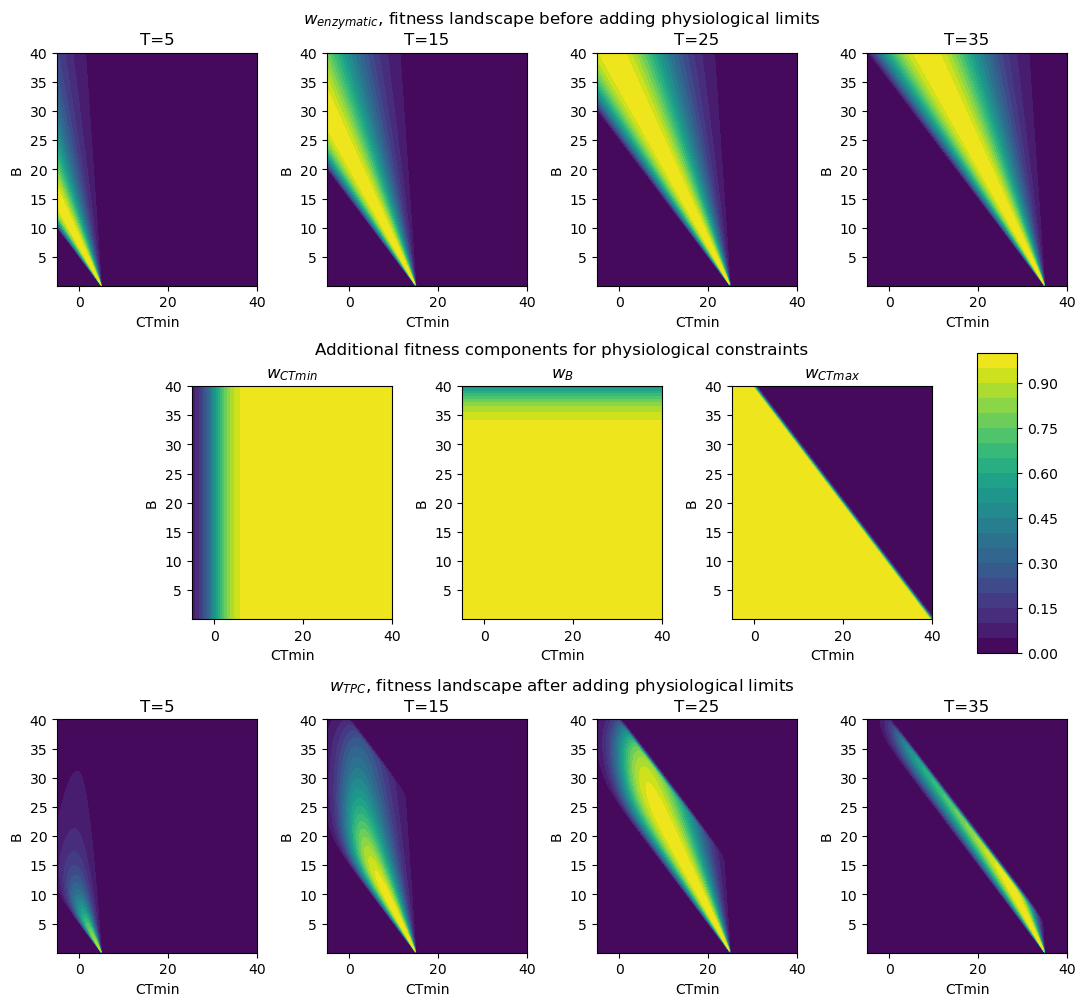

In [2]:
fig = plt.figure(figsize=(10,10))
subfigs = fig.subfigures(nrows=3, ncols=1)
width = 0.2
space = 0.07
bottom = 0.15
height = 0.7

CTmin_list = np.linspace(-2, 40, 100)
B_list = np.linspace(0.01, 40, 100)

# Generate fitness landscape for 4 temperatures 
Tlist = [5, 15, 25, 35]
B_list = np.linspace(1e-3, 40, 300)
CTmin_list = np.linspace(-5, 40, 450)
CTmax_list = np.linspace(-5, 50, 500) # purely for plotting fitness component for CTmax
[CTmin_grid, B_grid] = np.meshgrid(CTmin_list, B_list)
CTmax_grid = CTmin_grid + B_grid

levels = np.linspace(0, 1, 21)

    
# Make contours 
C1_contour = tpc_object.w_CTmin(CTmin=CTmin_grid)
C2_contour = tpc_object.w_B(B=B_grid)
C3_contour = tpc_object.w_CTmax(CTmax=CTmax_grid)
components = [C1_contour, C2_contour, C3_contour]
components_titles = [r"$w_{CTmin}$", r"$w_{B}$", r"$w_{CTmax}$"]

plt.rcParams.update({'font.size': 10})
# Top row
subfigs[0].suptitle(r"$w_{enzymatic}$, fitness landscape before adding physiological limits")
left_space = (1 - width * len(Tlist) - space * (len(Tlist)-1)) / 2
for i, T in enumerate(Tlist):
    P_contour = tpc_object.w_enzymatic(CTmin=CTmin_list, B=B_list, T=T)
    ax = subfigs[0].add_axes([left_space + (width + space) * i, bottom, width, height])
    ax.contourf(CTmin_grid, B_grid, P_contour, levels=levels)
    ax.set_title(f"T={T}")
    ax.set_xlabel("CTmin")
    ax.set_ylabel("B")

# Middle row
subfigs[1].suptitle("Additional fitness components for physiological constraints")
left_space = (1 - width * len(components) - space * (len(components)-1)) / 2
for i, contour in enumerate(components):
    ax = subfigs[1].add_axes([left_space + (width + space) * i, bottom, width, height])
    ax.contourf(CTmin_grid, B_grid, contour, levels=levels)
    ax.set_title(components_titles[i])
    ax.set_xlabel("CTmin")
    ax.set_ylabel("B")

# Last row
subfigs[2].suptitle(r"$w_{TPC}$, fitness landscape after adding physiological limits")
left_space = (1 - width * len(Tlist) - space * (len(Tlist)-1)) / 2
for i, T in enumerate(Tlist):
    W_contour = tpc_object.w_TPC(CTmin=CTmin_list, B=B_list, T=T)
    ax = subfigs[2].add_axes([left_space + (width + space) * i, bottom, width, height])
    contour = ax.contourf(CTmin_grid, B_grid, W_contour, levels=levels)
    ax.set_title(f"T={T}")
    ax.set_xlabel("CTmin")
    ax.set_ylabel("B")
cbar_ax = fig.add_axes([0.915, 0.35, 0.04, 0.3])
cbar = fig.colorbar(contour, cax=cbar_ax, extend='max')
fig.savefig("../figures/fitness_components_2d.pdf", bbox_inches='tight')